# Scalar DM production + Q-stallis

This notebook implements (and cleans up) a numerical pipeline inspired by **1006.2518v3** for the real singlet scalar DM model:

1. Define the model and parameters.
2. Compute Higgs total width $\Gamma_h(\lambda,m_D)$ including $h\to SS$ when open.
3. Compute reduced annihilation cross sections $\hat\sigma(s)$ for $SS\to f\bar f,\ WW,\ ZZ,\ hh$.
4. Compute the thermal average $\langle\sigma v\rangle(x)$ with a numerically stable integral.
5. Solve the Boltzmann equation for the yield $Y(x)$.
6. For each $m_D$, solve for $\lambda$ such that $\Omega_D h^2 \approx 0.11$.
7. Produce the main diagnostic plots (similar to Fig. 1, 3, 4).

**Conventions**
- Units: **GeV** throughout.
- Natural units $\hbar=c=1$: $\langle\sigma v\rangle$ is in **$\text{GeV}^{-2}$**.
- We provide explicit conversion to **$\text{cm}^3$/s** for indirect detection plots.


### Necessary imports to run the notebook

In [1]:
!pip install particle
!pip install shapely
!pip install multiprocess tqdm

In [2]:
#To get the masses
from particle import Particle
#To compute thermal avg cs
import numpy as np
import scipy as scp
from scipy.special import kve
#To solve Boltzmann equation
from scipy.integrate import solve_ivp
from scipy.optimize import brentq
from scipy.interpolate import interp1d
#To visualize results
import matplotlib.pyplot as plt
from shapely.geometry import LineString
import pandas as pd
import warnings
import os
# to multiprocesses
from multiprocess import Pool, cpu_count
from functools import partial
from tqdm.notebook import tqdm
import itertools

In [3]:
# --- SM masses in GeV ---
m_n = 0.9395654133  # nucleon mass 

# --- Boson masses ---
m_h = 125.20  # Higgs mass in GeV
m_w = Particle.from_evtgen_name("W+").mass * 1e-3
m_z = Particle.from_evtgen_name("Z0").mass * 1e-3

# --- Fermion masses ---
m_e   = Particle.from_evtgen_name("e-").mass   * 1e-3
m_mu  = Particle.from_evtgen_name("mu-").mass  * 1e-3
m_tau = Particle.from_evtgen_name("tau-").mass * 1e-3

# --- Quark masses ---
m_qu = Particle.from_evtgen_name("u").mass * 1e-3
m_qd = Particle.from_evtgen_name("d").mass * 1e-3
m_qs = Particle.from_evtgen_name("s").mass * 1e-3
m_qc = Particle.from_evtgen_name("c").mass * 1e-3
m_qb = Particle.from_evtgen_name("b").mass * 1e-3
m_qt = Particle.from_evtgen_name("t").mass * 1e-3

SM_leptons = [m_e, m_mu, m_tau]                    # charged leptons
SM_quarks  = [m_qu, m_qd, m_qs, m_qc, m_qb, m_qt]   # quarks (we include 3 colors in rates)

# --- Other constants ---
vev  = 246.22          # Higgs vev in GeV
m_pl = 1.2209e19       # Planck mass in GeV
g_star = 90.0          # effective relativistic degrees of freedom (kept constant here)

# --- Unit conversion: (cm^3/s) <-> (GeV^-2) ---
CM_TO_GEV_INV = 5.0677307e13   # 1 cm  = 5.0677e13 GeV^-1
S_TO_GEV_INV  = 1.5192674e24   # 1 s   = 1.5193e24 GeV^-1
CM3_PER_S_TO_GEV_M2 = (CM_TO_GEV_INV**3) / S_TO_GEV_INV  # (cm^3/s) -> (GeV^-2)
GEV_M2_TO_CM3_PER_S = 1.0 / CM3_PER_S_TO_GEV_M2          # (GeV^-2) -> (cm^3/s)

print(f"Conversion: 1 GeV^-2 = {GEV_M2_TO_CM3_PER_S:.3e} cm^3/s")
print(f"m_h = {m_h} GeV, m_n = {m_n} GeV")

# --- Data to extrapole Degrees of freedom ---
T_data = [10e3,5e3,2e3,1e3,500,200,100,50,20,10,5,2,1,0.5,0.214,0.2139999,0.200,0.190,0.180,0.170,0.16999999,0.160,0.150,0.149999,0.140,0.130,0.100,0.050,0.020,0.010,0.005, 0.002,0.001,500e-6,200e-6,100e-6,50e-6,20e-6,10e-6]
g_star_s_data = [106.75,106.75,106.74,106.70, 106.56,105.61,102.85, 96.53, 88.14, 86.13,85.37,81.80, 75.50,68.55,62.25,62.25,61.99, 61.83, 61.67,61.52, 61.52,61.38, 61.25, 24.77,22.59,20.86,17.55,14.32, 11.25, 10.76, 10.74,10.70,10.56,10.03, 7.55, 4.78,3.93,3.91,3.91]
g_star_energy_density_data = [106.75,106.75,106.74,106.72,106.61,105.90,103.53,97.40,88.45,86.22,85.60,82.50,76.34,69.26,62.49,62.49,62.21,62.03,61.87,61.72,61.72,61.58,61.45,26.32,23.77,21.76,18.00,14.63,11.33,10.76,10.74,10.71,10.60,10.16,7.66,4.46,3.39,3.36, 3.36]

g_star_s_funct= interp1d(T_data, g_star_s_data, kind='linear', fill_value="extrapolate")
g_star_energy_density_funct = interp1d(T_data, g_star_energy_density_data, kind='linear', fill_value="extrapolate")

# second trial

Conversion: 1 GeV^-2 = 1.167e-17 cm^3/s
m_h = 125.2 GeV, m_n = 0.9395654133 GeV


# Q-Tsallis statistics + Boltzmann eq

Tsallis statistics is a deviation from the traditional Boltzmann-Gibbs (BG) statistics. We supouse DM does not follow BG, instead they follow a similar statistics, changing the **cosmology**. Following a Curado–Tsallis–type
“R–formalism” this changes:

- Radiation thermodynamics is deformed by two functions:
  - $R_\rho(q)$: modifies the energy density $\rho_R$.
  - $R_n(q)$: modifies the number density $n_R$.
- This affects:
  - The **equilibrium yield** $Y_{\rm eq}^q$.
  - The **entropy density** $s_q(T)$.
  - The **Hubble rate** $H_q(T)$ (because $H^2 \propto \rho_R$).
  - And therefore the **Boltzmann equation** and the relic abundance.

### Tsallis functions

We will start by defining the q-exponential and R $_\rho$(q) functions

In [4]:
###################Q-EXPONENTIAL######################
def q_exp(x: float, q: float) ->float:
# Safety check for q=1 (standard exponential)
    if abs(q - 1.0) < 1e-3: 
        return np.exp(x)
    if q==1: return np.exp(x)
        
    # Base calculation
    base = 1 + (1 - q) * x
    
    # Safety: If base <= 0, q-exp is defined as 0 (cutoff)
    if base <= 0:
        return 0.0
        
    return base**(1 / (1 - q))

###################R_rho function######################
def R_rho_integrand(z: float, q: float) -> float:
    return z**3 * q_exp(-z,q)
    
def R_rho(q: float) -> float:
    opts = {'limit': 200, 'epsrel': 1e-6} 
    z_min = 0.0
    
    # Determine Upper Bound
    if q >= 1:
        z_max = np.inf
    else:
        z_max = 1 / (1 - q)

    integral_result, _ = scp.integrate.quad(
        R_rho_integrand,
        z_min,
        z_max,
        args=(q,), 
        **opts      
    )
    if np.abs(integral_result / 6 - 1.0) <  1e-5: return 1
    return integral_result / 6

###################R_v_eval function######################

def R_n_integrand(z: float, q: float) -> float:
    return z**2 * q_exp(-z,q)
    
def R_n(q: float) -> float:
    opts = {'limit': 200, 'epsrel': 1e-6} 
    z_min = 0.0
    
    # Determine Upper Bound
    if q >= 1:
        z_max = np.inf
    else:
        z_max = 1 / (1 - q)

    integral_result, _ = scp.integrate.quad(
        R_n_integrand,
        z_min,
        z_max,
        args=(q,), 
        **opts      
    )
    
    if np.abs(integral_result /2 -1) < 1e-5: return 1
    return integral_result / 2

# Quick numerical check for some q-values
for q_test in [1.0, 0.9, 1.05]:
    print(
        f"q = {q_test:.2f} -> R_rho(q) = {R_rho(q_test):.4f}, "
        f"R_n(q) = {R_n(q_test):.4f}"
    )

q = 1.00 -> R_rho(q) = 1.0000, R_n(q) = 1.0000
q = 0.90 -> R_rho(q) = 0.4163, R_n(q) = 0.5828
q = 1.05 -> R_rho(q) = 1.7200, R_n(q) = 1.3760


### Thermal avg cross sections $\langle\sigma v\rangle(x)$

For non-relativistic WIMPs, the **thermally averaged cross section** can be written as an integral over the Mandelstam variable $s$ (Gondolo & Gelmini):

$$
\langle \sigma v \rangle(x) = \frac{x}{8 m_D^5 K_2^2(x)}\int_{4m_D^2}^{\infty} ds\, \sigma(s) \, (s - 4m_D^2) \sqrt{s} \, K_1\!\left(\frac{\sqrt{s}}{T}\right),
$$

where $x = m_D / T$ and $K_n$ are modified Bessel functions of the second kind.

The original code implements this integral in a numerically stable way by:

- Defining a **scaled equilibrium density** `n_eq_scaled` that factors out an $e^{-x}$.
- Defining an integrand `integrand_scaled` with a compensating $e^{-(z-2x)}$` factor so the numerics do not underflow for large $x$.
- The **overall equilibrium density** is rescaled by $R_n(q)$,
  and the radiation background (Hubble rate) is rescaled via $R_\rho(q)$.

We keep that strategy here, and then build an interpolation function `interpol_sigma(lamb, m_d, x_min, x_max)` that returns $\ln \langle \sigma v \rangle(x)$ on a grid in $x$. This interpolation is what makes the Boltzmann solver faster.


In [5]:
#EQUILIBRIUM DENSITY#################################
def n_q_eq_scaled(m_d: float, x: float, R_n: float) -> float:
    """
    Scaled equilibrium number density:
    n_eq = (m^3 / (2π^2 x)) K2(x)
    Return n_eq_scaled = (m^3 / (2π^2 x)) kve(2,x) = e^{x} n_eq.
    """
    if x <= 0: return 0.0
    return R_n* (m_d**3/(x*2*np.pi**2))* kve(2, x)

#THERMAL AVERAGED CROSS SECTIONS######################

# --- Integrand ---
def integrand_scaled_q(s: float, lamb: float, m_d: float, x: float,cs_model_dependent) -> float:
    # 1. Physics Threshold
    if s < 4 * m_d**2: return 0.0
    
    # 2. Bessel Argument and scaling factor
    z = x * np.sqrt(s) / m_d
    exponential_factor = np.exp(-(z - 2 * x ))
    
    # 3. Get Cross Section
    sigma = cs_model_dependent(lamb, m_d, s)
    
    return sigma * np.sqrt(s) * kve(1, z) * exponential_factor

# -- Full term ---
def thermal_avg_cs_q(lamb: float, m_d: float ,x: float,cs_model_dependent,R_n: float) -> float:
    # --- Settings as resonance points and limits ---   
    s_min = 4 * m_d**2
    s_split = (4*m_qt**2+500)
    s_split = max(s_split, s_min + 1.0)
        
    thresholds = [4*m_w**2, 4*m_z**2, m_h**2,4*m_h**2, 4*m_qt**2]
    active_points = [p for p in thresholds if p > s_min]
    opts_finite = {'limit': 200, 'epsrel': 1e-4, 'points': active_points}
    opts_tail = {'limit': 200, 'epsrel': 1e-4} 
    
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")

        # --- Actual integration ---
        I1, _ = scp.integrate.quad(
            integrand_scaled_q, 
            s_min, 
            s_split, 
            args=(lamb, m_d, x,cs_model_dependent), 
            **opts_finite
        )
    
        I2, _ = scp.integrate.quad(
            integrand_scaled_q, 
            s_split, 
            np.inf, 
            args=(lamb, m_d, x,cs_model_dependent), 
            **opts_tail
        )

    integral_val = I1 + I2

    # --- Final result ---
    denom = n_q_eq_scaled(m_d, x,R_n)**2 * 64 * np.pi**4 * x
    if denom == 0: return 0.0
    return m_d/denom * integral_val

#INTERPOLING THERMAL AVERAGED CROSS SECTIONS
def interpol_sigma_q(lamb: float, m_d: float, x_min: float, x_max: float, cs_model_dependent, R_n_eval: float) -> float:
    x_range = np.logspace(np.log10(x_min), np.log10(x_max), 200)
    vals = []
    SAFE_FLOOR = 1e-90
    for x_val in x_range:
        sigma = thermal_avg_cs_q(lamb, m_d, x_val, cs_model_dependent, R_n_eval)
        
        if sigma <= 0:
            vals.append(SAFE_FLOOR)
        else:
            vals.append(sigma)
    return interp1d(x_range, np.log(vals), kind='cubic', fill_value="extrapolate")



### Boltzmann equation


$$
\frac{dY_q}{dx} =
- \frac{s_q(x)}{x\,H_q(x)}\,\langle\sigma v\rangle_q
\left(Y_q^2 - Y_{q,\rm eq}^2\right),
$$

with:

- $s_q(T) \propto R_n(q)\,T^3$,
- $H_q(T) = \sqrt{R_\rho(q)}\,H_{\rm BG}(T)$,
- $Y_{q,\rm eq} = n_q^{\rm eq} / s_q$.

This keeps the **same structure** as in the BG case but replaces the thermodynamic
quantities by their $q$-deformed versions.

> Important: we compute $R_n(q)$ and $R_\rho(q)$ **once per value of q**
> and then pass them as numbers (`R_n_q`, `R_rho_q`) to all functions. This
> avoids recomputing integrals inside the ODE solver.

In [6]:
######## Entropy density, Hubble factor, Yield in equilibrium ##################
def s_q_of_T(m_d: float, x: float, R_n: float) -> float:
    """Entropy density."""
    return R_n*(2 * np.pi**2 / 45.0) * g_star * (m_d/x)**3

def H_q_of_T(m_d: float, x: float, R_n: float) -> float:
    return np.sqrt(8*np.pi /3) * np.sqrt(3*(m_d/x)*s_q_of_T(m_d,x,R_n)/4)/m_pl

def Y_eq_q(m_d: float, x: float, R_n: float, R_rho_eval: float) -> float:
    """Equilibrium yield Y_eq = n_eq / s as function of x = mchi/T."""
    if x <= 0:
        return 0.0
    return n_q_eq_scaled(m_d,x,R_n) / s_q_of_T(m_d,x,R_rho_eval) * np.exp(-x)


################### Differential equation #############################
def dYdx_q(x: float, Y, m_d: float, interpol_sigma, R_n_eval: float, R_rho_eval: float):

    # --- Extrapolating degrees of freedom ---
    T = m_d/x
    gs,ge = g_star_s_funct(T), g_star_energy_density_funct(T)

    # --- Loading thermal averaged cross sections ---
    sigmav = np.exp(interpol_sigma(x))

    # --- Writting down the equation ---
    dY = -np.sqrt(np.pi/45)*np.sqrt(R_rho_eval)*(gs/np.sqrt(ge))*m_d*m_pl* sigmav/(x**2)*(Y**2 - Y_eq_q(m_d,x,R_n_eval,R_rho_eval)**2)
    return dY


#################### Solving the equation ##############################
def sol_q_boltz(m_d: float, lamb: float, cs_model_dependent, R_n_eval: float ,R_rho_eval: float):
    # --- Interpolating thermal averaged cross section ---
    x_ini, x_max = 0.1, 200.0
    sigma_interp_q = interpol_sigma_q(lamb, m_d, x_ini, x_max, cs_model_dependent, R_n_eval)

    # --- Obtaining border condition ---
    Y0 = Y_eq_q(m_d,x_ini,R_n_eval,R_rho_eval)
    
    # --- Solving the equation ---
    sol_q = solve_ivp(
        dYdx_q,
        (x_ini, x_max),
        [Y0],
        method="Radau",
        rtol=1e-8,
        atol=1e-12,
        args=(m_d,sigma_interp_q,R_n_eval,R_rho_eval)
    )
    
    # --- Retriving results ---
    x  = sol_q.t
    Y  = sol_q.y[0]
    return x,Y
    

## Inverting the relic abundance in q-cosmology


The relation between $Y_\infty$ and $\Omega h^2$ is **unchanged**:

$$
\Omega_D h^2 = 2.74 \times 10^8 \left( \frac{m_D}{\mathrm{GeV}} \right) Y_\infty.
$$

So the **target yield** is still

$$
Y_{\rm target}(m_D) = \frac{0.11}{2.74 \times 10^8}\,\frac{1}{m_D},
$$

and we again solve

$$
Y_\infty^q(m_D, \lambda; q) - Y_{\rm target}(m_D) = 0
$$

for $\lambda = \lambda_q(m_D)$.

We simply reuse `relic_target_Y(m_d)` from the BG section, but now with
the **q-deformed solver** `sol_q_boltz`.

In [7]:
# --- Recovering relic abundance ---
def relic_target_Y(m_d, omega_h2_target=0.11):
    """Target asymptotic yield that reproduces Omega h^2 ~ omega_h2_target."""
    return omega_h2_target / (m_d * 2.74e8)

# -- Minimizing the error between the necessary Yield and the Yield recovered ---
def obj_q(lamb: float, m_d: float, cs_model_dependent, R_n_eval: float, R_rho_eval: float):
    Y_target = relic_target_Y(m_d)
    _,Y = sol_q_boltz(m_d, lamb, cs_model_dependent, R_n_eval,R_rho_eval)
    return(Y[-1]-Y_target)

# --- Obtaining the couplings ---
def coupling_q(m_d: float, cs_model_dependent, R_n_eval: float, R_rho_eval: float,lamb_min=1e-5, lamb_max=1.0 ):
    """
    Find the coupling λ_q(m_D) in Tsallis cosmology that reproduces
    the target relic abundance.

    If no solution is found in [lamb_min, lamb_max], return np.nan.
    """
    try:
        lamb_sol = brentq(
            obj_q,
            lamb_min,
            lamb_max,
            args=(m_d, cs_model_dependent, R_n_eval, R_rho_eval,),
            xtol=1e-5,
            rtol=1e-5)
        return lamb_sol
    except ValueError:
        return np.nan

# Normal BG statistics

To compare we also solve the usual **Boltzmann equation** for the yield $Y = n/s$:

$$
\frac{dY}{dx} = -\frac{s(x)}{x H(x)}\langle \sigma v \rangle \left(Y^2 - Y_{\rm eq}^2\right),
$$

with $x = m_D/T$.

We define:

* $H(x)$ using $H(T) = \sqrt{\frac{4\pi^3 g_*}{45}}\,\frac{T^2}{M_{\rm Pl}}$ with $T = m_D/x$.
* $s(x)$ using $s(T) = \frac{2\pi^2}{45} g_* T^3$.
* $Y_{\rm eq}(x) = n_{\rm eq}(x) / s(x)$, with $n_{\rm eq}$ using `n_eq_scaled` and our $e^{-x}$ factor.

For a given mass $m_D$ and coupling $\lambda$, we:

1. Precompute `sigma_interp = interpol_sigma(lamb, m_d, x_ini, x_max)`.
2. Solve the ODE from $x_{\rm ini}$ to $x_{\rm max}$ using `solve_ivp`.
3. Extract the asymptotic yield $Y_\infty \equiv Y(x_{\rm max})$.

Then, we **invert** this relation using a root finder to get, for each $m_D$,
the value of $\lambda(m_D)$ that gives the observed relic abundance.

Observed relic density constraint:

$$
\Omega_{\rm DM} h^2 \simeq 0.11 \quad (\text{we use 0.11 as in the original code}),
$$

and we solve for $\lambda$ such that the final yield satisfies this.

### Thermal avg cross sections

In [8]:
#EQUILIBRIUM DENSITY#################################
def n_eq_scaled(m_d: float, x: float) -> float:
    """Escaled number density"""
    if x <= 0: return 0.0
    return (1/(2*np.pi**2)) * (m_d**3)/x * kve(2, x)

#THERMAL AVERAGED CROSS SECTIONS######################
def integrand_scaled(s: float, lamb: float, m_d: float, x: float) -> float:
    # 1. Physics Threshold
    if s < 4 * m_d**2: return 0.0
    
    # 2. Bessel Argument and scaling factor
    z = x * np.sqrt(s) / m_d
    exponential_factor = np.exp(-(z - 2 * x ))
    
    # 3. Get Cross Section
    sigma = cs(lamb, m_d, s)
    
    return sigma * np.sqrt(s) * kve(1, z) * exponential_factor

#We will now obtain the full term
def thermal_avg_cs(lamb: float, m_d: float, x: float) -> float:
    """Thermal averaged cross section for BG statistics"""
    s_min = 4 * m_d**2
    s_split = (4*m_qt**2+500)
    s_split = max(s_split, s_min + 1.0)
        
    thresholds = [4*m_w**2, 4*m_z**2, m_h**2,4*m_h**2, 4*m_qt**2]
    active_points = [p for p in thresholds if p > s_min]
    opts_finite = {'limit': 200, 'epsrel': 1e-4, 'points': active_points}
    opts_tail = {'limit': 200, 'epsrel': 1e-4} 
    
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        integral_val_1, _ = scp.integrate.quad(
            integrand_scaled, 
            s_min, 
            s_split, 
            args=(lamb, m_d, x), 
            **opts_finite
        )
    
        integral_val_2, _ = scp.integrate.quad(
            integrand_scaled, 
            s_split, 
            np.inf, 
            args=(lamb, m_d, x), 
            **opts_tail
        )

    integral_val = integral_val_1 + integral_val_2

    denom = n_eq_scaled(m_d, x)**2 * 64 * np.pi**4 * x
    if denom == 0: return 0.0
    return m_d/denom * integral_val

#INTERPOLING THERMAL AVERAGED CROSS SECTIONS
def interpol_sigma(lamb: float, m_d: float, x_min: float, x_max: float)-> float:
    """Interpolating thermal averaged cross sections in BG statistics"""
    x_range = np.logspace(np.log10(x_min), np.log10(x_max), 200)
    vals = []
    SAFE_FLOOR = 1e-90
    for x_val in x_range:
        sigma = thermal_avg_cs(lamb, m_d, x_val)
        
        if sigma <= 0:
            vals.append(SAFE_FLOOR)
        else:
            vals.append(sigma)
    return interp1d(x_range, np.log(vals), kind='cubic', fill_value="extrapolate")


### Boltzmann equation

In [9]:
#FACTORS NEEDED TO SOLVE B EQ in R formalism##########################
def s_of_T(m_d: float, x: float) -> float:
    """Entropy density."""
    return (2 * np.pi**2 / 45.0) * g_star * (m_d/x)**3

def H_of_T(m_d: float) -> float:
    """Hubble rate evaluated at x==1"""
    return np.sqrt(4*np.pi**3 * g_star/45) * (m_d**2/m_pl)

def Y_eq(m_d: float, x: float) -> float:
    """Equilibrium yield Y_eq = n_eq / s as function of x = mchi/T."""
    if x <= 0:
        return 0.0
    return n_eq_scaled(m_d,x) / s_of_T(m_d,x) * np.exp(-x)

def dYdx(x: float, Y, m_d: float,interpol_sigma):
    """Boltzmann equation in terms of x = mchi/T."""       
    sigmav = np.exp(interpol_sigma(x))
    dY =  -x*s_of_T(m_d,x)* sigmav*(Y**2 - Y_eq(m_d,x)**2) /H_of_T(m_d)
    return dY


def sol_boltz(m_d: float, lamb: float):
    x_ini, x_max = 0.1, 200.0
    sigma_interp = interpol_sigma(lamb, m_d, x_ini, x_max)
    Y0 = Y_eq(m_d,x_ini)
    
    sol = solve_ivp(
        dYdx,
        (x_ini, x_max),
        [Y0],
        method="Radau",
        rtol=1e-8,
        atol=1e-12,
        args=(m_d,sigma_interp)
    )
    
    x  = sol.t
    Y  = sol.y[0]
    return x,Y

In [10]:
def obj(lamb: float, m_d: float):
    Y0 = 0.11/(m_d*2.74*1e8)
    _,Y = sol_boltz(m_d,lamb)
    return(Y[-1]-Y0)

def coupling(m_d: float):
    try:
        lamb_sol = brentq(obj, 1e-5, 1.0, args=(m_d,),xtol=1e-5,rtol=1e-5)
        return lamb_sol
        
    except ValueError:
        return np.nan

# Real Scalar Singlet

The real scalar singlet is the simpliest model of DM. it consists of a real scalar $S$ under $Z_2$ symmetry whose interactions with the SM are mediated through the Higgs boson.

Its Lagrangean is the Following 
$$
\mathcal{L} = \mathcal{L}_{SM} + \frac{1}{2}\partial_\mu S \partial^\mu S - \frac{m_0^2}{2}S^2 - \frac{\lambda_s}{4}S^4 -\lambda S^2 H^\dagger H
$$
After EWSB, $H \to (0, (v + h)/\sqrt{2})^T$, and the physical DM mass is

$$
m_D^2 = m_0^2 + \lambda v^2.
$$


Its governed by three free parameters: $m_0, \, \lambda_s, \, \lambda$, here: 
+ $m_0$: DM mass
+ $\lambda_s$: Self-interaction strengh
+ $\lambda$: Interactions with Higgs, i.e Annihilations

## Loading the physics

**Higgs Decay Width $\Gamma_h$**

We now compute the Higgs total width $\Gamma_h$ as the sum of:

* A **SM part** $\Gamma_{h,\rm SM}$ (approximated or taken from PDG).
* A **dark matter part** $\Gamma(h \to SS)$ when kinematically allowed.

The DM partial width is (as in the reference singlet-scalar literature):

$$
\Gamma(h \to SS) = \frac{\lambda^2 v^2}{8\pi m_h^2} \sqrt{m_h^2 - 4m_D^2}\,,\quad (m_h > 2 m_D),
$$

otherwise it is zero.

For the SM width, we can either:

* Approximate it via partial widths to fermions, **or**
* Simply take a numerical value close to the PDG one.

In [11]:
# Naive fermionic partial width estimate (not used as final total, just for illustration), Accounts for
# 1.- Three colors of quarks
# 2.- Higgs is not massive enough to decay to ZZ, W+W- or 2 tops quarks
# 3.- Check for kinematic thresholds due to DM mass


Gamma_h_SM_fermions = 0.0

for m_f in SM_leptons:
    if m_h > 2 * m_f:
        Gamma_h_SM_fermions += (m_f**2) / (8 * np.pi * vev**2) * (m_h**2 - 4 * m_f**2)**1.5 / (m_h**2)

for m_f in SM_quarks:
    if m_h > 2 * m_f:
        # 3 colors
        Gamma_h_SM_fermions += 3.0 * (m_f**2) / (8 * np.pi * vev**2) * (m_h**2 - 4 * m_f**2)**1.5 / (m_h**2)

print(f"Naive fermionic partial width ~ {Gamma_h_SM_fermions:.3e} GeV")

# In practice we use an effective SM total width that includes off-shell decays
Gamma_h_SM_now = 3.7e-3  # GeV, effective SM width used in the original code

def Gamma_h_DM(lamb: float, m_d: float) -> float:
    """Partial width for h -> S S."""
    if m_h > 2 * m_d:
        return (lamb**2 * vev**2) / (8 * np.pi) * np.sqrt(m_h**2 - 4 * m_d**2) / (m_h**2)
    return 0.0

def Gamma_h(lamb: float, m_d: float) -> float:
    """Total Higgs width: SM + invisible to dark matter."""
    return Gamma_h_SM_now + Gamma_h_DM(lamb, m_d)

print(f"Example: Gamma_h(lambda=1e-3, m_D=60 GeV) = {Gamma_h(1e-3, 60.0):.3e} GeV")

Naive fermionic partial width ~ 4.946e-03 GeV
Example: Gamma_h(lambda=1e-3, m_D=60 GeV) = 3.705e-03 GeV


**Reduced cross sections $\hat\sigma(s)(SS -> SM)$**


We now implement the **total annihilation cross section** $\sigma(SS \to \text{SM})$ via an $s$-channel Higgs propagator, following the structure of the singlet-scalar reference (Yu, Tang & Feng, etc.).

The function `cs(lamb, m_d, s)` returns:

- $SS\to f\bar f$ (leptons and quarks; quarks include **3 colors**),
- $SS\to W^+W^-, ZZ$ when open,
- $SS\to hh$ when open.

At the end, we multiply by the flux factor $\sqrt{1 - 4 m_D^2 / s}$ to obtain the quantity $\sigma_\text{tot}(s)$ that will be used inside the thermal average integral.



In [12]:
#Cross sections per incident flux

# Auxiliary Function F(xi) for Higgs channel (Eq 5 text)
def F(xi: float) -> float:
    if xi < 1e-5: return 1.0       # Limit x->0
    if xi >= 1.0: return 1.0       # Singularity protection
    return np.arctanh(xi) / xi

def cs(lamb: float, m_d: float, s: float) -> float:
    """
    Calculates the total annihilation cross section sigma_hat * sqrt(1 - 4m_d^2/s).
    This returns the full integrand part for Eq (7) except the Bessel function.
    """
    # 1. Kinematic Threshold for DM annihilation
    if s < 4 * m_d**2: return 0.0
    
    # 2. Pre-calculate common factors
    width = Gamma_h(lamb, m_d)
    denom = (s - m_h**2)**2 + (m_h * width)**2
    propagator = 1.0 / denom

    result = 0.0
    # Leptons
    for m_f in SM_leptons:
        if s > 4 * m_f**2:
            result += (lamb * m_f)**2 / np.pi * propagator * (s - 4 * m_f**2)**1.5 / np.sqrt(s)
            
    # Quarks
    for m_f in SM_quarks:
        if s > 4 * m_f**2:
            result += 3.0 * (lamb * m_f)**2 / np.pi * propagator * (s - 4 * m_f**2)**1.5 / np.sqrt(s)

    # WW Channel
    if s > 4 * m_w**2:
        beta_w = np.sqrt(1 - 4 * m_w**2 / s)
        factor_w = 1 - 4 * m_w**2 / s + 12 * m_w**4 / s**2
        result += (lamb**2) / (2 * np.pi) * s**2 * propagator * beta_w * factor_w
        
    # ZZ Channel
    if s > 4 * m_z**2:
        beta_z = np.sqrt(1 - 4 * m_z**2 / s)
        factor_z = 1 - 4 * m_z**2 / s + 12 * m_z**4 / s**2
        result += (lamb**2) / (4 * np.pi) * s**2 * propagator * beta_z * factor_z

    # Higgs Channel
    if s > 4 * m_h**2:
        xi = np.sqrt((s - 4 * m_h**2) * (s - 4 * m_d**2)) / (s - 2 * m_h**2)
        term1 = ((s + 2 * m_h**2) / (s - m_h**2))**2
        term2 = (16 * lamb * vev**2) / (s - 2 * m_h**2) *((s + 2 * m_h**2) / (s - m_h**2)) * F(xi)
        term3 = (32 * lamb**2 * vev**4) / ((s - 2 * m_h**2)**2) * (1 / (1 - xi**2) + F(xi))
        result += (lamb**2) / (4 * np.pi) * np.sqrt(1 - 4 * m_h**2 / s) * (term1 - term2 + term3)

    # 6. Apply Flux Factor (Eq 9)
    return result * np.sqrt(1 - (4 * m_d**2) / s)

# Quick sanity check at some point in parameter space
print(f"cs(lambda=1e-3, m_D=60 GeV, s=(2*m_D)^2) = {cs(1e-3, 60.0, (2*60.0)**2):.3e} GeV^-2")
        

cs(lambda=1e-3, m_D=60 GeV, s=(2*m_D)^2) = 0.000e+00 GeV^-2


## Computing the couplings for each mass

In [25]:
import os

# Force libraries to use only 1 thread per process
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["VECLIB_MAXIMUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"

import multiprocess as mp
from itertools import product
from tqdm import tqdm
import pandas as pd
import numpy as np

import importlib
import physics_engine
importlib.reload(physics_engine)


if __name__ == "__main__":
    # Parameters
    q_values = np.linspace(0.05, 1.25, 25)
    masses = np.linspace(10, 200, 150) 
    
    args = [(q, m) for q, m in product(q_values, masses)]

    ctx = mp.get_context('spawn')

    # Use the worker from the file
    with ctx.Pool(processes=mp.cpu_count()) as pool:
        results = list(tqdm(
            pool.imap(physics_engine.worker_task, args), 
            total=len(args)
        ))

    # Process and Save
    df = pd.DataFrame(results)
    df_pivoted = df.pivot(index='mass', columns='q', values='result')
    
    output_file = "/home/ethan/repos/DM-tsallis-q-statistics/Data_created/Tsallis_multi_process.csv"
    df_pivoted.to_csv(output_file)
    print(f"Success! Data saved to {output_file}")

Load sucessfull!


  0%|          | 0/3750 [00:00<?, ?it/s]

Load sucessfull!
Load sucessfull!
Load sucessfull!
Load sucessfull!
Load sucessfull!
Load sucessfull!
Load sucessfull!
Load sucessfull!
Load sucessfull!
Load sucessfull!
Load sucessfull!
Load sucessfull!


 96%|█████████▌| 3588/3750 [10:15:42<18:30,  6.85s/it]  /home/ethan/repos/DM-tsallis-q-statistics/Scripts/physics_engine.py:92: IntegrationWarning: The maximum number of subdivisions (200) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  integral_result, _ = scp.integrate.quad(
 96%|█████████▌| 3590/3750 [10:15:53<17:00,  6.38s/it]/home/ethan/repos/DM-tsallis-q-statistics/Scripts/physics_engine.py:92: IntegrationWarning: The maximum number of subdivisions (200) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local diff

Success! Data saved to /home/ethan/repos/DM-tsallis-q-statistics/Data_created/Tsallis_multi_process.csv


In [10]:
real_scalar_couplings_multi = pd.read_csv(r'/home/ethan/repos/DM-tsallis-q-statistics/Data_created/Tsallis_multi_process.csv')
n_cols = len(real_scalar_couplings_multi.columns)
masses = real_scalar_couplings_multi.iloc[:,0]
couplings = [real_scalar_couplings_multi.iloc[:,n] for n in range(1,n_cols)]
q_values = np.linspace(0.05, 1.25, 25)

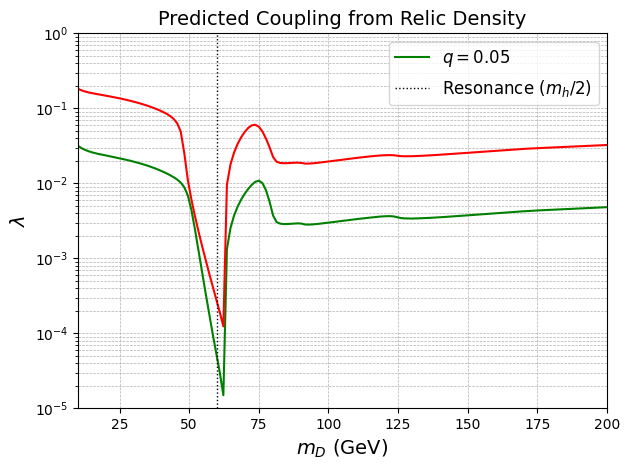

In [11]:
plt.plot(masses,couplings[0], color='green', linewidth=1.5, label=f'$q = {q_values[0]}$')
plt.plot(masses,couplings[-1], color='red', linewidth=1.5)
#plt.plot(masses,couplings[2], color='red', linewidth=1.5)
#plt.plot(masses,couplings[3], color='black', linewidth=1.5, label =f'$q = {q_values[3]}$')
#plt.plot(masses,couplings[4], color='red', linewidth=1.5)
#plt.plot(masses,couplings[5], color='red', linewidth=1.5)
#plt.plot(masses,couplings[6], color='Blue', linewidth=1.5, label=f'$q = {q_values[-1]}$')

# Set Logarithmic Scale on Y-axis
plt.yscale('log')

# Formatting labels and limits to match the paper style
plt.xlabel(r'$m_D$ (GeV)', fontsize=14)
plt.ylabel(r'$\lambda$', fontsize=14)
plt.title('Predicted Coupling from Relic Density', fontsize=14)

# Set limits similar to Figure 1 
plt.xlim(10, 200)
plt.ylim(1e-5, 1.0)  # Adjust lower limit if your resonance dip goes deeper
plt.axvline(x=60, color='black', linestyle=':', linewidth=1.0, label='Resonance ($m_h/2$)')
# Add grid and legend
plt.grid(True, which="both", linestyle='--', linewidth=0.5)
plt.legend(fontsize=12)

# Show the plot

plt.tight_layout()
plt.savefig(r'C:\Users\PC Astrobi\Desktop\Programas U\github\DM-tsallis-q-statistics\Plots' + '\\' + 'Couplings_multi')
plt.show()

## Dark Matter Direct Search

In [12]:
# Constants from text below Eq. 14
# Order corresponds to: Up, Down, Strange (Light quarks)
f_q_functions = [0.014, 0.036, 0.118] 
f_g_function = 0.83

# CORRECTED Eq. 16: Added m_h**2
def a_q(lamb, m_q, m_d):
    return (lamb * m_q) / (m_d * m_h**2)

def f_n(lamb, m_d):
    f_n_val = 0
    
    # We assume SM_quarks is ordered: [u, d, s, c, b, t]
    # The first 3 are "Light" (direct contribution)
    # The last 3 are "Heavy" (gluon contribution)
    
    for i, m_q in enumerate(SM_quarks):
        # Calculate a_q once
        coupling = a_q(lamb, m_q, m_d)
        
        if i < 3:
            # Eq 14 First term (Light quarks)
            f_n_val += f_q_functions[i] * coupling * m_n / m_q
        else:
            # Eq 14 Second term (Heavy quarks -> Gluons)
            f_n_val += (2 / 27) * f_g_function * coupling * m_n / m_q
            
    return f_n_val

# Eq. 15
def sigma_SI_n(lamb, m_d):
    reduced_mass = (m_d * m_n) / (m_d + m_n)
    return (4 / np.pi) * reduced_mass**2 * f_n(lamb, m_d)**2

In [13]:
############# PREDICTED DATA#####################
sig_spin_independent_total = []

for j,q in enumerate(q_values):

    sig_spin_independent = [sigma_SI_n(couplings[j][i],m_d)/CM_TO_GEV_INV**2 for i,m_d in enumerate(masses)] 
    real_scalar_couplings_multi[f'sigma_SI (q ={q})'] = sig_spin_independent
    sig_spin_independent_total.append(sig_spin_independent) 
    

real_scalar_couplings_multi.to_csv(r'/home/ethan/repos/DM-tsallis-q-statistics/Data_created/dm_results_q_scan_linux_computations.csv', index=False)    

############ EXPERIMENTAL DATA #################
#--------------------Xenon100 (2016)
xenon100 = pd.read_csv(r'/home/ethan/repos/DM-tsallis-q-statistics/Experimental_Data/HEPData-ins1463250-v1-Table_1.csv', comment='#')
masses1, cs1 = xenon100["WIMP mass [GeV/$c^2$]"].tolist(), xenon100["WIMP-nucleon cross section [cm$^2$]"].tolist()

#-------------------LZ 2023
LZ_2023 = pd.read_csv(r'/home/ethan/repos/DM-tsallis-q-statistics/Experimental_Data/HEPData-ins2107834-v1-SI_cross_section.csv', comment='#')

first_header_repeat = LZ_2023[LZ_2023['mass'] == 'mass'].index
if len(first_header_repeat) > 0:
    LZ_2023 = LZ_2023.iloc[:first_header_repeat[0]]

LZ_2023['mass'] = pd.to_numeric(LZ_2023['mass'], errors='coerce')
LZ_2023['pc_limit'] = pd.to_numeric(LZ_2023['pc_limit'], errors='coerce')
LZ_2023 = LZ_2023.dropna()
masses2, cs2 = LZ_2023["mass"].tolist(), LZ_2023["pc_limit"].tolist()

#--------------------LZ TONE YEARS 2025
LZ_TONE_YRS_2025 = pd.read_csv(r'/home/ethan/repos/DM-tsallis-q-statistics/Experimental_Data/HEPData-ins2841863-v2-SI_cross_section.csv', comment='#')

first_header_repeat = LZ_TONE_YRS_2025[LZ_TONE_YRS_2025['mass'] == 'mass'].index
if len(first_header_repeat) > 0:
    LZ_TONE_YRS_2025 = LZ_TONE_YRS_2025.iloc[:first_header_repeat[0]]

LZ_TONE_YRS_2025['mass'] = pd.to_numeric(LZ_TONE_YRS_2025['mass'], errors='coerce')
LZ_TONE_YRS_2025['limit'] = pd.to_numeric(LZ_TONE_YRS_2025['limit'], errors='coerce')
LZ_TONE_YRS_2025 = LZ_TONE_YRS_2025.dropna()
masses3, cs3 = LZ_TONE_YRS_2025["mass"].tolist(), LZ_TONE_YRS_2025["limit"].tolist()

#-------------------LZ 2025
LZ_2025 = pd.read_csv(r'/home/ethan/repos/DM-tsallis-q-statistics/Experimental_Data/HEPData-ins3091049-v2-SI_cross_section.csv', comment='#')

first_header_repeat = LZ_2025[LZ_2025['mass'] == 'mass'].index
if len(first_header_repeat) > 0:
    LZ_2025 = LZ_2025.iloc[:first_header_repeat[0]]

LZ_2025['mass'] = pd.to_numeric(LZ_2025['mass'], errors='coerce')
LZ_2025['limit'] = pd.to_numeric(LZ_2025['limit'], errors='coerce')
LZ_2025 = LZ_2025.dropna()
masses4, cs4 = LZ_2025["mass"].tolist(), LZ_2025["limit"].tolist()

#-------------------Storing in lists for nice plots
experimental_lines = [
    (masses1, cs1, "XENON100 (2016)", "blue"),
    (masses2, cs2, "LZ (2023)", "red"),
    (masses3, cs3, "LZ-TONNE-YRS (2025)", "green"),
    (masses4, cs4, "LZ (2025)", "purple"),
]

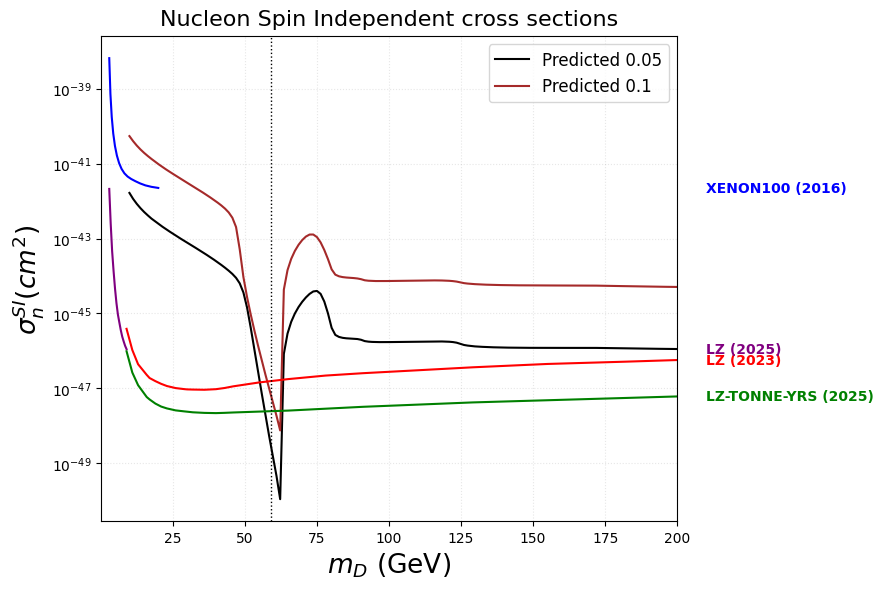

In [14]:
fig, ax = plt.subplots(figsize=(9, 6))
#True sigmas
ax.plot(masses,sig_spin_independent_total[0], color="black", linestyle="solid", label=f"Predicted {q_values[0]}")
ax.plot(masses,sig_spin_independent_total[-1], color="brown", linestyle="solid", label=f"Predicted {q_values[1]}")
#ax.plot(masses,sig_spin_independent_total[2], color="red", linestyle="solid", label=f"Predicted {q_values[2]}")
#ax.plot(masses,sig_spin_independent_total[3], color="black", linestyle="solid", label=f"Predicted {q_values[3]}")
#ax.plot(masses,sig_spin_independent_total[4], color="red", linestyle="solid", label=f"Predicted {q_values[4]}")
#ax.plot(masses,sig_spin_independent_total[5], color="red", linestyle="solid", label=f"Predicted {q_values[5]}")
#ax.plot(masses,sig_spin_independent_total[6], color="Blue", linestyle="solid", label=f"Predicted {q_values[6]}")

#Experimental data
for m, cs_exp, label, color in experimental_lines:
    line, = ax.plot(m, cs_exp, color=color, linestyle="solid")
    
    x_pos = 200
    y_pos = np.interp(200, m, cs_exp)
    
    ax.text(x_pos * 1.05, y_pos, label, color=color, 
            fontsize=10, va='center', fontweight='bold')

# Axes labels and title
ax.set_xlabel(r"$m_D$ (GeV)", fontsize=19)
ax.set_ylabel(r"$\sigma_n^{SI} (cm^2) $", fontsize=19)
ax.set_title(r"Nucleon Spin Independent cross sections", fontsize=16, pad=8)

# Limits
ax.set_xlim(0.1, 200)
# Light grid for readability
ax.grid(True, which="both", ls=":", alpha=0.3)
ax.set_yscale("log")
# Legend
ax.legend(loc='upper right', fontsize=12, frameon=True)

plt.axvline(x=59, color='black', linestyle=':', linewidth=1.0)
# Tight layout and save for LaTeX
fig.tight_layout()

# Save inside Images/ for your LaTeX includegraphics
plt.savefig(r'/home/ethan/repos/DM-tsallis-q-statistics/Plots/Nucleon_SI_cs_multi_linux')
plt.show()

In [21]:
#####################Obtaining the available parameter space###################################

min_q = LineString(np.column_stack((masses, sig_spin_independent_total[0])))
normal =LineString(np.column_stack((masses, sig_spin_independent_total[1])))
#max_q = LineString(np.column_stack((masses, sig_spin_independent_total[-1])))
LZ_2025_line = LineString(np.column_stack((masses3, cs3)))

intersections_min_q = min_q.intersection(LZ_2025_line)
intersections_norm = normal.intersection(LZ_2025_line)
#intersections_max_q = max_q.intersection(LZ_2025_line)

# This returns the exact geometric crossing point
# Extracting them individually
point_1_min_q = intersections_min_q .geoms[0]
point_2_min_q = intersections_min_q .geoms[1]

point_1_norm = intersections_norm .geoms[0]
point_2_norm = intersections_norm .geoms[1]

#point_1_max_q = intersections_max_q .geoms[0]
#point_2_max_q = intersections_max_q .geoms[1]

# Getting the x (mass) and y (cross section)
m1_min_q, m2_min_q = point_1_min_q.x, point_2_min_q.x
m1_norm, m2_norm = point_1_norm.x, point_2_norm.x
#m1_max_q, m2_max_q = point_1_max_q.x, point_2_max_q.x

print(f"the available parameter space for {q_values[0]} is: {round(m1_min_q,3)} <= m_d <= {round(m2_min_q,3)} GeV")
print(f"the usual available parameter space for {q_values[1]} is: {round(m1_norm,3)} <= m_d <= {round(m2_norm,3)} GeV")
#print(f"the available parameter space for {q_values[-1]} is: {round(m1_max_q,3)} <= m_d <= {round(m2_max_q,3)} GeV")

the available parameter space for 0.918 is: 61.863 <= m_d <= 57.402 GeV
the usual available parameter space for 1.082 is: 61.819 <= m_d <= 60.847 GeV


## Dark Matter Indirect search

Using the couplings obtained from reproducing the relic abundance, we can compute the thermal average cross section at x = $3 \times 10^6$, which plays an important role at the annihilation in the galactic halo.

In [45]:
# 1. Define the analytic halo helper (if you haven't already)
def halo_cross_section(lamb, m_d):
    s_threshold = 4 * m_d**2 + 1e-10 
    sigma_hat = cs(lamb, m_d, s_threshold) * (1- 4*m_d**2 /s_threshold)**(-0.5)
    return sigma_hat / (4 * m_d**2)

# 2. Run the loop using the ANALYTIC function
sigma_halo_cm3_s_total = []
conversion_factor = 1.167e-17

for j,q in enumerate(q_values):
    sigma_halo_cm3_s = [halo_cross_section(couplings[j][i], md)*conversion_factor for i,md in enumerate(masses)]
    real_scalar_couplings_multi[f'sigma_halo (q ={q})'] = sigma_halo_cm3_s
    sigma_halo_cm3_s_total.append(sigma_halo_cm3_s) 


real_scalar_couplings_multi.to_csv(r'C:\Users\PC Astrobi\Desktop\Programas U\github\DM-tsallis-q-statistics\Data_created\dm_results_q_scan_computations.csv', index=False)

data = [
    {"n": 0, "x": 10.3126, "y": 1.061908e-28},
    {"n": 1, "x": 10.7668, "y": 1.077975e-28},
    {"n": 2, "x": 11.0352, "y": 1.077975e-28},
    {"n": 3, "x": 11.3103, "y": 1.094285e-28},
    {"n": 4, "x": 11.5923, "y": 1.094285e-28},
    {"n": 5, "x": 11.9547, "y": 1.094285e-28},
    {"n": 6, "x": 12.7924, "y": 1.127649e-28},
    {"n": 7, "x": 13.4382, "y": 1.144710e-28},
    {"n": 8, "x": 13.9439, "y": 1.162030e-28},
    {"n": 9, "x": 14.4686, "y": 1.197460e-28},
    {"n": 10, "x": 15.1991, "y": 1.233969e-28},
    {"n": 11, "x": 16.0651, "y": 1.290832e-28},
    {"n": 12, "x": 17.4037, "y": 1.391484e-28},
    {"n": 13, "x": 21.8561, "y": 2.183386e-28},
    {"n": 14, "x": 23.2440, "y": 2.537160e-28},
    {"n": 15, "x": 26.1284, "y": 3.084114e-28},
    {"n": 16, "x": 30.4759, "y": 3.748979e-28},
    {"n": 17, "x": 34.8964, "y": 4.557174e-28},
    {"n": 18, "x": 38.5089, "y": 5.216645e-28},
    {"n": 19, "x": 39.4691, "y": 5.375697e-28},
    {"n": 20, "x": 40.4531, "y": 5.623413e-28},
    {"n": 21, "x": 41.4617, "y": 5.882544e-28},
    {"n": 22, "x": 42.2346, "y": 6.061899e-28},
    {"n": 23, "x": 43.5549, "y": 6.534576e-28},
    {"n": 24, "x": 45.473, "y": 7.150688e-28},
    {"n": 25, "x": 46.6068, "y": 7.593374e-28},
    {"n": 26, "x": 47.7688, "y": 8.185467e-28},
    {"n": 27, "x": 48.6593, "y": 9.092758e-28},
    {"n": 28, "x": 49.5664, "y": 9.950069e-28},
    {"n": 29, "x": 53.367, "y": 1.384536e-27 },
    {"n": 30, "x": 54.3618, "y": 1.515077e-27},
    {"n": 31, "x": 54.6976, "y": 1.708475e-27},
    {"n": 32, "x": 55.7172, "y": 2.238721e-27},
    {"n": 33, "x": 56.4075, "y": 2.601461e-27},
    {"n": 34, "x": 57.1064, "y": 3.022977e-27},
    {"n": 35, "x": 58.5302, "y": 4.334675e-27},
    {"n": 36, "x": 61.1077, "y": 7.669775e-27},
    {"n": 37, "x": 62.6313, "y": 9.900387e-27},
    {"n": 38, "x": 64.1928, "y": 1.099776e-26},
    {"n": 39, "x": 65.7933, "y": 1.203469e-26},
    {"n": 40, "x": 67.8501, "y": 1.336863e-26},
    {"n": 41, "x": 71.7158, "y": 1.625061e-26},
    {"n": 42, "x": 77.6916, "y": 1.916941e-26},
    {"n": 43, "x": 84.6852, "y": 2.194342e-26},
    {"n": 44, "x": 88.9606, "y": 2.330190e-26},
    {"n": 45, "x": 99.3862, "y": 2.588472e-26},
    {"n": 46, "x": 106.35, "y": 2.707751e-26},
    {"n": 47, "x": 111.719, "y": 2.790308e-26},
    {"n": 48, "x": 120.286, "y": 2.832526e-26},
    {"n": 49, "x": 147.384, "y": 2.875383e-26},
    {"n": 50, "x": 154.824, "y": 2.832526e-26},
    {"n": 52, "x": 160.651, "y": 2.790308e-26},
    {"n": 53, "x": 169.803, "y": 2.707751e-26},
    {"n": 54, "x": 185.089, "y": 2.549892e-26},
    {"n": 55, "x": 194.433, "y": 2.437567e-26},
    {"n": 56, "x": 205.511, "y": 2.295459e-26},
    {"n": 57, "x": 218.561, "y": 2.129418e-26},
    {"n": 58, "x": 231.013, "y": 1.945944e-26},
    {"n": 59, "x": 244.175, "y": 1.751775e-26},
    {"n": 60, "x": 256.502, "y": 1.576980e-26},
    {"n": 61, "x": 271.116, "y": 1.377623e-26},
    {"n": 62, "x": 284.804, "y": 1.203469e-26},
    {"n": 63, "x": 291.904, "y": 1.099776e-26},
    {"n": 64, "x": 299.182, "y": 9.752825e-27},
    {"n": 65, "x": 306.642, "y": 8.648813e-27},
    {"n": 66, "x": 316.228, "y": 6.700188e-27},
    {"n": 67, "x": 328.128, "y": 5.269133e-27},
    {"n": 68, "x": 336.309, "y": 4.672671e-27},
    {"n": 69, "x": 342.578, "y": 4.081968e-27},
    {"n": 70, "x": 353.288, "y": 3.565939e-27},
    {"n": 71, "x": 364.332, "y": 3.068715e-27},
    {"n": 72, "x": 378.042, "y": 2.601461e-27},
    {"n": 73, "x": 392.268, "y": 2.205354e-27},
    {"n": 75, "x": 397.128, "y": 2.172484e-27},
    {"n": 76, "x": 412.072, "y": 2.108206e-27},
    {"n": 77, "x": 438.239, "y": 2.045830e-27},
    {"n": 78, "x": 451.939, "y": 2.015338e-27},
    {"n": 79, "x": 463.207, "y": 2.045830e-27},
    {"n": 80, "x": 480.638, "y": 2.076784e-27},
    {"n": 81, "x": 495.664, "y": 2.108206e-27},
    {"n": 82, "x": 520.688, "y": 2.172484e-27},
    {"n": 83, "x": 557.172, "y": 2.272593e-27},
    {"n": 84, "x": 574.59, "y": 2.341883e-27},
    {"n": 85, "x": 614.851, "y": 2.486865e-27},
    {"n": 86, "x": 653.895, "y": 2.640822e-27},
    {"n": 87, "x": 686.908, "y": 2.762513e-27},
    {"n": 88, "x": 735.039, "y": 2.977920e-27},
    {"n": 89, "x": 776.916, "y": 3.162278e-27},
    {"n": 90, "x": 806.152, "y": 3.307998e-27},
    {"n": 91, "x": 836.488, "y": 3.512790e-27},
    {"n": 92, "x": 889.606, "y": 3.902153e-27},
    {"n": 93, "x": 934.519, "y": 4.270068e-27},
    {"n": 94, "x": 981.7, "y": 4.743369e-27},
    {"n": 95, "x": 1037.63, "y": 5.348856e-27},
    {"n": 96, "x": 1096.75, "y": 6.122891e-27},
    {"n": 97, "x": 1159.23, "y": 7.008937e-27},
    {"n": 98, "x": 1225.28, "y": 7.903621e-27},
    {"n": 99, "x": 1295.09, "y": 8.912509e-27},
    {"n": 100, "x": 1368.87, "y": 1.005018e-26},
    {"n": 101, "x": 1455.8, "y": 1.133308e-26},
    {"n": 102, "x": 1538.74, "y": 1.258925e-26},
    {"n": 103, "x": 1719.07, "y": 1.530321e-26},
    {"n": 104, "x": 1862.32, "y": 1.751775e-26},
    {"n": 106, "x": 1956.34, "y": 1.916941e-26},
    {"n": 107, "x": 2080.57, "y": 2.129418e-26},
    {"n": 108, "x": 2240.1, "y": 2.437567e-26},
    {"n": 109, "x": 2338.75, "y": 2.667393e-26},
    {"n": 110, "x": 2456.83, "y": 2.963051e-26},
    {"n": 111, "x": 2596.8, "y": 3.291481e-26},
    {"n": 112, "x": 2744.75, "y": 3.711635e-26},
    {"n": 113, "x": 2901.13, "y": 4.185421e-26},
    {"n": 115, "x": 3047.59, "y": 4.580043e-26},
    {"n": 116, "x": 3301.54, "y": 5.242823e-26},
    {"n": 118, "x": 3446.94, "y": 5.651632e-26},
    {"n": 119, "x": 3620.96, "y": 6.001515e-26},
    {"n": 120, "x": 3803.77, "y": 6.469483e-26},
    {"n": 121, "x": 4120.72, "y": 7.186571e-26},
    {"n": 122, "x": 4491.66, "y": 7.864157e-26},
    {"n": 123, "x": 4776.88, "y": 8.477365e-26},
    {"n": 124, "x": 5080.22, "y": 9.002183e-26},
    {"n": 125, "x": 5503.53, "y": 9.559491e-26},
    {"n": 126, "x": 5925.53, "y": 1.015130e-25},
    {"n": 127, "x": 6340.73, "y": 1.077975e-25},
    {"n": 128, "x": 6826.92, "y": 1.127649e-25},
    {"n": 129, "x": 7817.14, "y": 1.233969e-25},
    {"n": 130, "x": 8313.54, "y": 1.271592e-25},
    {"n": 131, "x": 9230.83, "y": 1.350314e-25},
    {"n": 132, "x": 9696.86, "y": 1.370745e-25},
    {"n": 133, "x": 10061.8, "y": 1.370745e-25}
]
df_last = pd.DataFrame(data)   # data is your list of dicts
df_last = df_last.sort_values("x")

df_filtered = df_last[df_last['x'] <= 200].sort_values("x")

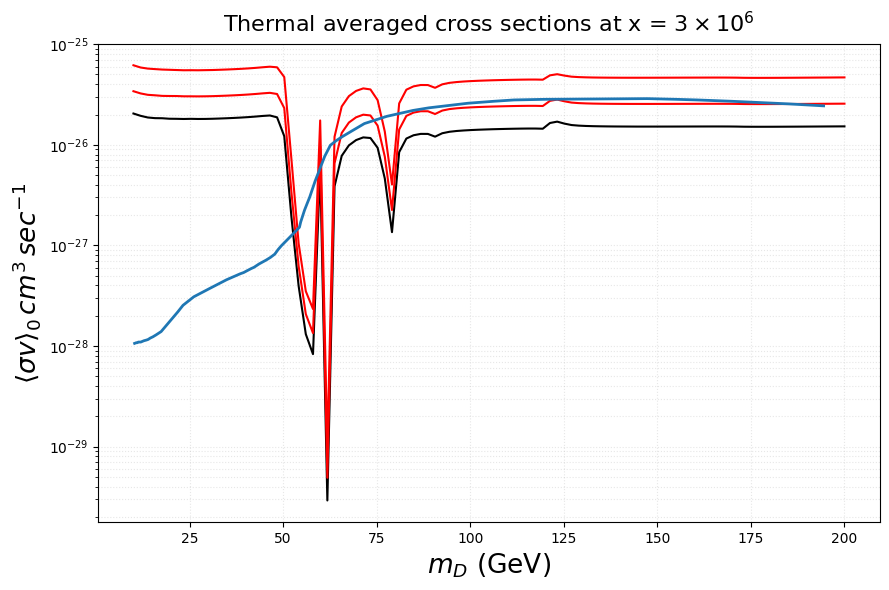

In [50]:
fig, ax = plt.subplots(figsize=(9, 6))
#True sigmas
ax.plot(masses,sigma_halo_cm3_s_total[0], color="black", linestyle="solid", label = f"Predicted q = {q_values[0]}")
ax.plot(masses,sigma_halo_cm3_s_total[1], color="red", linestyle="solid", label = f"Predicted q = {q_values[1]}")
ax.plot(masses,sigma_halo_cm3_s_total[2], color="red", linestyle="solid", label = f"Predicted q = {q_values[2]}")
#ax.plot(masses,sigma_halo_cm3_s_total[3], color="red", linestyle="solid", label = f"Predicted q = {q_values[3]}")
#ax.plot(masses,sigma_halo_cm3_s_total[4], color="red", linestyle="solid", label = f"Predicted q = {q_values[4]}")
#ax.plot(masses,sigma_halo_cm3_s_total[5], color="red", linestyle="solid", label = f"Predicted q = {q_values[5]}")
#ax.plot(masses,sigma_halo_cm3_s_total[6], color="Blue", linestyle="solid", label = f"Predicted q = {q_values[6]}")

ax.plot(df_filtered["x"], df_filtered["y"], lw=2.0, label="Last dictionary")
# Axes labels and title
ax.set_xlabel(r"$m_D$ (GeV)", fontsize=19)
ax.set_ylabel(r"$\langle \sigma v \rangle_0 \,  cm^3 \, sec^{-1}$", fontsize=19)
ax.set_title(r"Thermal averaged cross sections at x = $3 \times 10^6$", fontsize=16, pad=8)

# Limits
# Light grid for readability
ax.grid(True, which="both", ls=":", alpha=0.3)
ax.set_yscale("log")
# Legend


# Tight layout and save for LaTeX
fig.tight_layout()


# Save inside Images/ for your LaTeX includegraphics
plt.savefig(r'C:\Users\PC Astrobi\Desktop\Programas U\github\DM-tsallis-q-statistics\Plots' + '\\' + 'thermal_avg_cs')
plt.show()

## Branching ratio

In [47]:
branching_ratio_total = []

for q,_ in enumerate(q_values):
    branching_ratio = [Gamma_h_SM_now/Gamma_h(couplings[q][i],m_d) for i,m_d in enumerate(masses)] 
    real_scalar_couplings_multi[f'BR (q ={q})'] = branching_ratio
    branching_ratio_total.append(branching_ratio) 


real_scalar_couplings_multi.to_csv(r'C:\Users\PC Astrobi\Desktop\Programas U\github\DM-tsallis-q-statistics\Data_created\dm_results_q_scan_computations.csv', index=False)

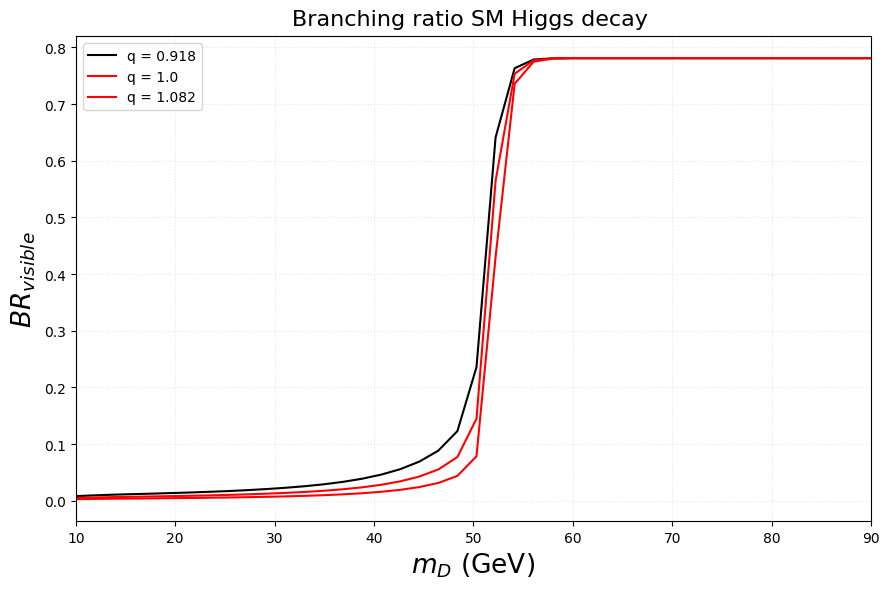

In [48]:
fig, ax = plt.subplots(figsize=(9, 6))
#True sigmas
ax.plot(masses,branching_ratio_total[0], color="black", linestyle="solid", label=f"q = {q_values[0]}")
ax.plot(masses,branching_ratio_total[1], color="red", linestyle="solid", label=f"q = {q_values[1]}")
ax.plot(masses,branching_ratio_total[2], color="red", linestyle="solid", label=f"q = {q_values[2]}")
#ax.plot(masses,branching_ratio_total[3], color="red", linestyle="solid", label=f"q = {q_values[3]}")
#ax.plot(masses,branching_ratio_total[4], color="red", linestyle="solid", label=f"q = {q_values[4]}")
#ax.plot(masses,branching_ratio_total[5], color="red", linestyle="solid", label=f"q = {q_values[5]}")
#ax.plot(masses,branching_ratio_total[6], color="Blue", linestyle="solid", label=f"q = {q_values[6]}")

# Axes labels and title
ax.set_xlabel(r"$m_D$ (GeV)", fontsize=19)
ax.set_ylabel(r"$BR_{visible}$", fontsize=19)
ax.set_title(r"Branching ratio SM Higgs decay ", fontsize=16, pad=8)

# Limits

# Light grid for readability
ax.grid(True, which="both", ls=":", alpha=0.3)
# Legend
ax.set_xlim(10, 90)
ax.legend()
# Tight layout and save for LaTeX
fig.tight_layout()



# Save inside Images/ for your LaTeX includegraphics

plt.savefig(r'C:\Users\PC Astrobi\Desktop\Programas U\github\DM-tsallis-q-statistics\Plots' + '\\' + 'BR.png')
plt.show()

# Safety checks

### Boltzmann equation solutions

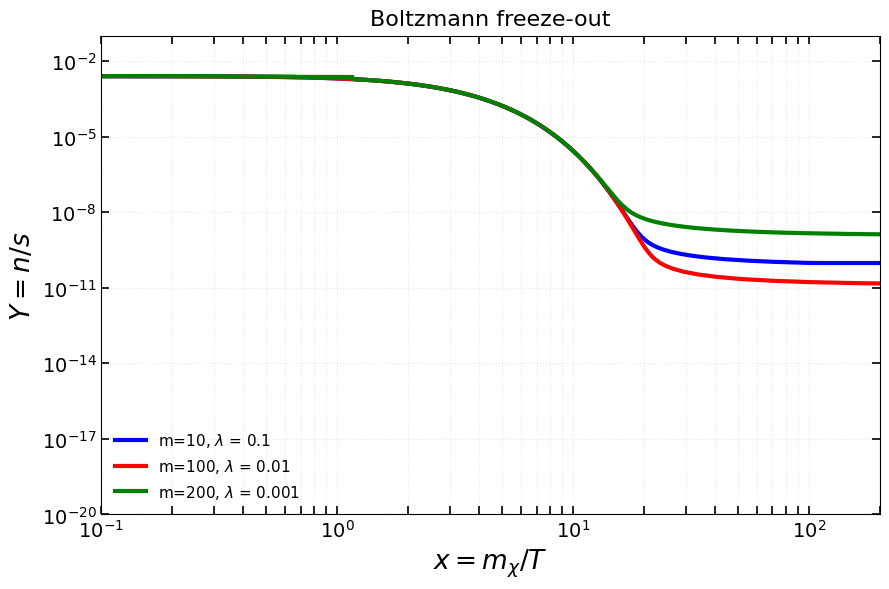

In [52]:
masses_test = [10,100,200]
lambda_test = [0.1,0.01,0.001]

x_test0, Y_0 = sol_boltz(masses_test[0],lambda_test[0])
x_test1, Y_1 = sol_boltz(masses_test[1],lambda_test[1])
x_test2, Y_2 = sol_boltz(masses_test[2],lambda_test[2])



# Use a single, clean figure
fig, ax = plt.subplots(figsize=(9, 6))

# Physical solution and equilibrium
ax.loglog(x_test0, Y_0,
          lw=3.0,
          label=fr"m={masses_test[0]}, $\lambda$ = {lambda_test[0]}", color="blue")

ax.loglog(x_test1, Y_1,
          lw=3.0,
          label=fr"m={masses_test[1]}, $\lambda$ = {lambda_test[1]}",color="red")

ax.loglog(x_test2, Y_2,
          lw=3.0,
          label=fr"m={masses_test[2]}, $\lambda$ = {lambda_test[2]}",color="green")

# Axes labels and title
ax.set_xlabel(r"$x = m_\chi/T$", fontsize=19)
ax.set_ylabel(r"$Y = n/s$", fontsize=19)
ax.set_title(r"Boltzmann freeze-out", fontsize=16, pad=8)

# Limits
ax.set_xlim(0.1, 200)
ax.set_ylim(1e-20, 1e-1)

# Ticks: size and style
ax.tick_params(axis="both", which="both",
               direction="in",
               length=6, width=1.2,
               labelsize=14,
               top=True, right=True)

# Light grid for readability
ax.grid(True, which="both", ls=":", alpha=0.3)

# Legend
ax.legend(loc="lower left",
          fontsize=11,
          frameon=False)

# Tight layout and save for LaTeX
fig.tight_layout()


# Save inside Images/ for your LaTeX includegraphics
path = r"/home/ethan/repos/DM-tsallis-q-statistics/Plots/Safety_checks/Boltz_solutions"
fig.savefig(path, dpi=300, bbox_inches="tight")
plt.show()

### Thermal Averaged cross sections (Interpolation)

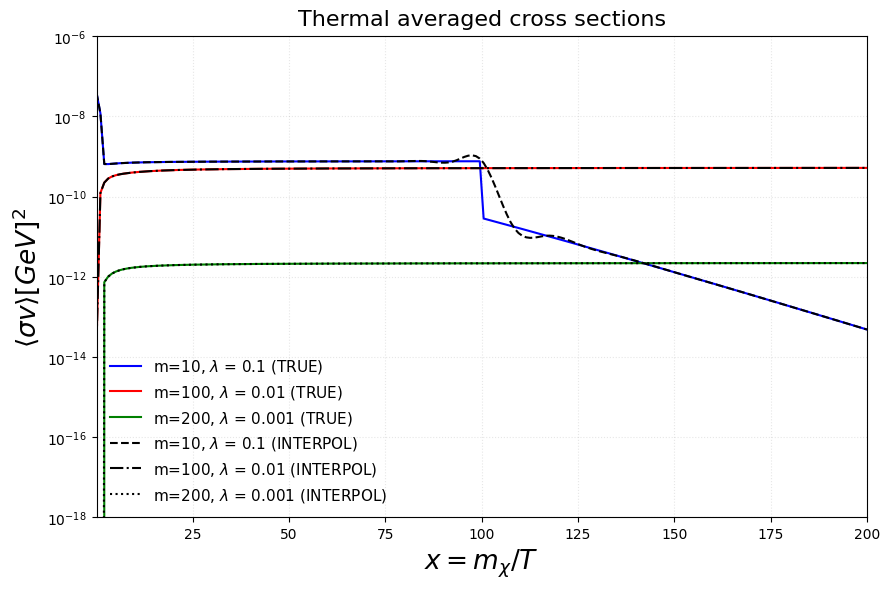

In [53]:
masses_test = [10,100,200]
lambda_test = [0.1,0.01,0.001]

#Storing results
sig_true0 = []
sig_true1 = []
sig_true2 = []

sig_interp0 = []
sig_interp1 = []
sig_interp2 = []
#Range of x to test
x_min_test, x_max_test = 0.1, 200
x_test = np.linspace(x_min_test, x_max_test,200)

#Generating true sigmas
for i in x_test: sig_true0.append(thermal_avg_cs(lambda_test[0], masses_test[0], i))
for i in x_test: sig_true1.append(thermal_avg_cs(lambda_test[1], masses_test[1], i))
for i in x_test: sig_true2.append(thermal_avg_cs(lambda_test[2], masses_test[2], i))

#Generating interpolated sigmas
f0 = interpol_sigma(lambda_test[0], masses_test[0], x_min_test, x_max_test)
f1 = interpol_sigma(lambda_test[1], masses_test[1], x_min_test, x_max_test)
f2 = interpol_sigma(lambda_test[2], masses_test[2], x_min_test, x_max_test)

sig_interp0 = np.exp(f0(x_test))
sig_interp1 = np.exp(f1(x_test))
sig_interp2 = np.exp(f2(x_test))

#--------------------Ploting-----------------------------------
fig, ax = plt.subplots(figsize=(9, 6))
#True sigmas
ax.plot(x_test,sig_true0, color="blue", linestyle="solid",label=fr"m={masses_test[0]}, $\lambda$ = {lambda_test[0]} (TRUE)")
ax.plot(x_test,sig_true1, color="red", linestyle="solid",label=fr"m={masses_test[1]}, $\lambda$ = {lambda_test[1]} (TRUE)")
ax.plot(x_test,sig_true2, color="green", linestyle="solid",label=fr"m={masses_test[2]}, $\lambda$ = {lambda_test[2]} (TRUE)")

#Interpoled sigmas 
ax.plot(x_test,sig_interp0, color="black", linestyle="--",label=fr"m={masses_test[0]}, $\lambda$ = {lambda_test[0]} (INTERPOL)")
ax.plot(x_test,sig_interp1, color="black", linestyle="-.",label=fr"m={masses_test[1]}, $\lambda$ = {lambda_test[1]} (INTERPOL)")
ax.plot(x_test,sig_interp2, color="black", linestyle=":",label=fr"m={masses_test[2]}, $\lambda$ = {lambda_test[2]} (INTERPOL)")

# Axes labels and title
ax.set_xlabel(r"$x = m_\chi/T$", fontsize=19)
ax.set_ylabel(r"$\langle \sigma v \rangle [GeV]^2$", fontsize=19)
ax.set_title(r"Thermal averaged cross sections", fontsize=16, pad=8)

# Limits
ax.set_xlim(0.1, 200)
ax.set_ylim(1e-18,1e-6 )

# Light grid for readability
ax.grid(True, which="both", ls=":", alpha=0.3)
ax.set_yscale("log")
# Legend
ax.legend(loc="lower left",
          fontsize=11,
          frameon=False)

# Tight layout and save for LaTeX
fig.tight_layout()


# Save inside Images/ for your LaTeX includegraphics
path = r"/home/ethan/repos/DM-tsallis-q-statistics/Plots/Safety_checks/thermal_avg_cs_interpol"
fig.savefig(path, dpi=300, bbox_inches="tight")
plt.show()

### Degrees of freedom (interpolation)

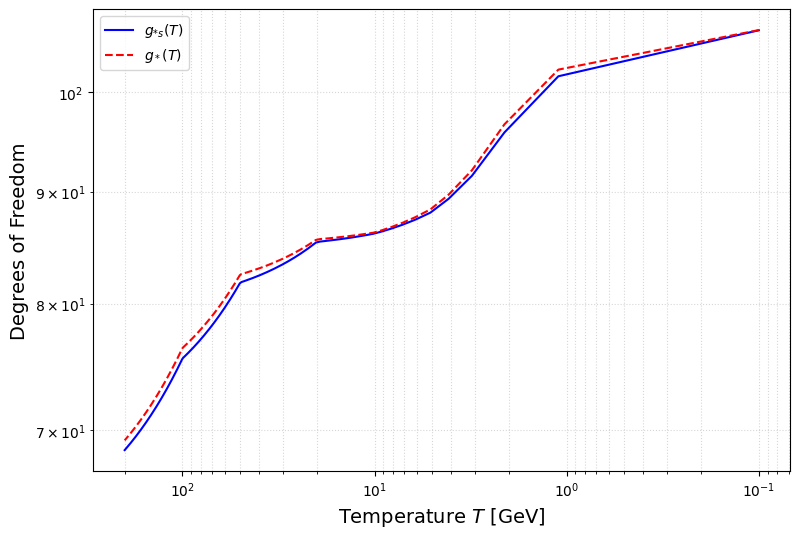

In [54]:
#--------Checking degrees of freedom-------
t_range = np.logspace(-5, 4, 500) 
x_range = np.linspace(0.1,200,200)
fig, ax = plt.subplots(figsize=(9, 6))

#-----------Ploting--------------
ax.plot(x_range, g_star_s_funct(100/x_range), color="blue", label=r"$g_{*s}(T)$")
ax.plot(x_range, g_star_energy_density_funct(100/x_range), color="red", linestyle="--", label=r"$g_*(T)$")

ax.set_xscale("log")
ax.set_yscale("log") # Husdal Fig 1 uses linear y-axis
ax.set_xlabel(r"Temperature $T$ [GeV]", fontsize=14)
ax.set_ylabel(r"Degrees of Freedom", fontsize=14)
ax.invert_xaxis() # High T on the left (Early Universe)
ax.grid(True, which="both", ls=":", alpha=0.5)
ax.legend()

path = r"/home/ethan/repos/DM-tsallis-q-statistics/Plots/Safety_checks/DOF_interpol"
fig.savefig(path, dpi=300, bbox_inches="tight")

plt.show()

### Tsallis statistics limit (q->1)

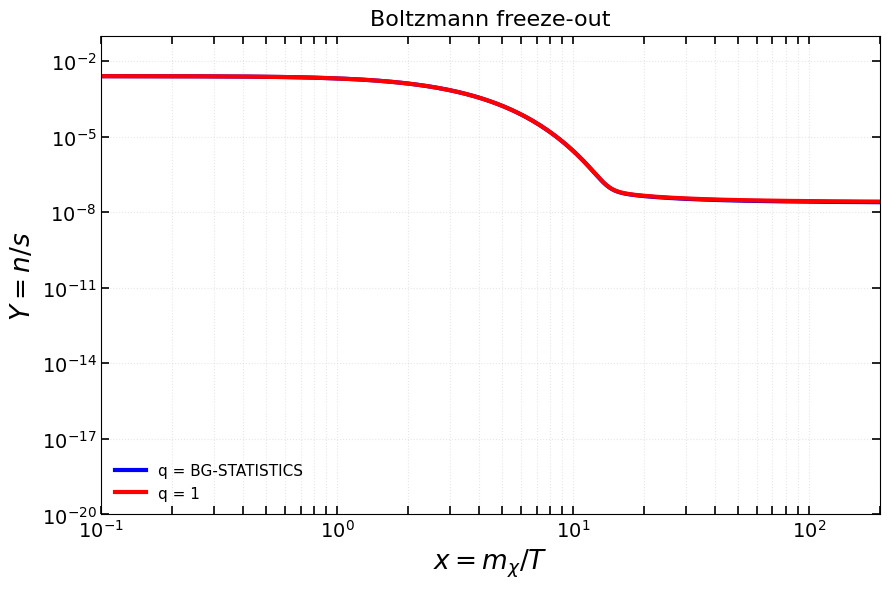

In [76]:
#---------Solving Boltzmann equation
q = 1.00000
rho, n = R_rho(q), R_n(q)

x, y = sol_boltz(40,0.001)
x_q, y_q = sol_q_boltz(40,0.001, cs,n, rho)

#----------Ploting------------------
# Use a single, clean figure
fig, ax = plt.subplots(figsize=(9, 6))

# Physical solution and equilibrium
ax.loglog(x, y,
          lw=3.0,
          label=fr"q = BG-STATISTICS ", color="blue")

ax.loglog(x_q, y_q,
          lw=3.0,
          label=fr"q = 1 ", color="red")


# Axes labels and title
ax.set_xlabel(r"$x = m_\chi/T$", fontsize=19)
ax.set_ylabel(r"$Y = n/s$", fontsize=19)
ax.set_title(r"Boltzmann freeze-out", fontsize=16, pad=8)

# Limits
ax.set_xlim(0.1, 200)
ax.set_ylim(1e-20, 1e-1)

# Ticks: size and style
ax.tick_params(axis="both", which="both",
               direction="in",
               length=6, width=1.2,
               labelsize=14,
               top=True, right=True)

# Light grid for readability
ax.grid(True, which="both", ls=":", alpha=0.3)

# Legend
ax.legend(loc="lower left",
          fontsize=11,
          frameon=False)

# Tight layout and save for LaTeX
fig.tight_layout()


# Save inside Images/ for your LaTeX includegraphics
path = r"/home/ethan/repos/DM-tsallis-q-statistics/Plots/Safety_checks/q_limit"
fig.savefig(path, dpi=300, bbox_inches="tight")
plt.show()

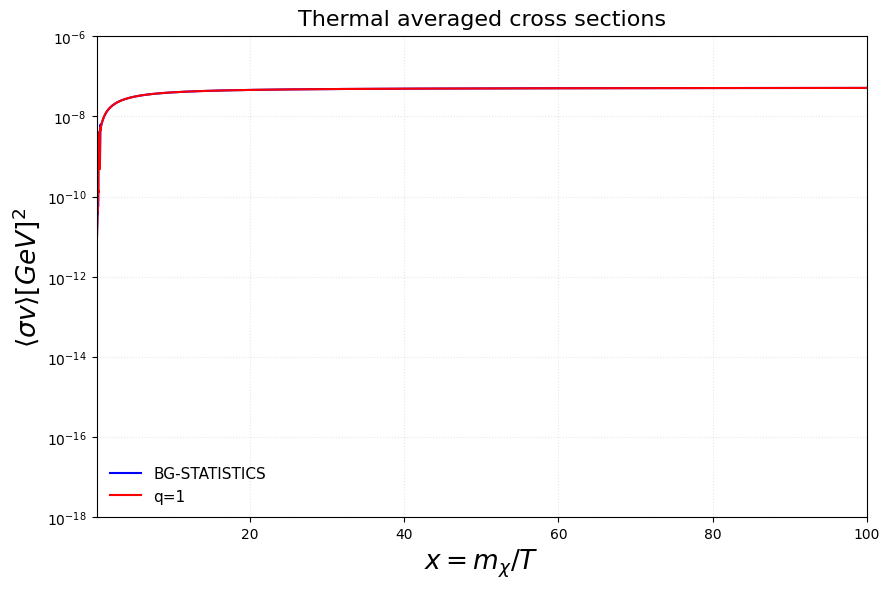

In [61]:
#-----------Computing Thermal averaged cross sections

x_range = np.logspace(-1,2,200)
sigma, sigma_q = interpol_sigma(0.1,100,0.1,200), interpol_sigma_q(0.1,100,0.1,200,cs,1)
sigma1 = np.exp(sigma(x_range))
sigma2 = np.exp(sigma_q(x_range))

#-------------Ploting--------------------
fig, ax = plt.subplots(figsize=(9, 6))
#True sigmas
ax.plot(x_range,sigma1, color="blue", linestyle="solid",label=fr"BG-STATISTICS")
ax.plot(x_range,sigma2, color="red", linestyle="solid",label=fr"q=1")

# Axes labels and title
ax.set_xlabel(r"$x = m_\chi/T$", fontsize=19)
ax.set_ylabel(r"$\langle \sigma v \rangle [GeV]^2$", fontsize=19)
ax.set_title(r"Thermal averaged cross sections", fontsize=16, pad=8)

# Limits
ax.set_xlim(0.1, 100)
ax.set_ylim(1e-18,1e-6 )

# Light grid for readability
ax.grid(True, which="both", ls=":", alpha=0.3)
ax.set_yscale("log")
# Legend
ax.legend(loc="lower left",
          fontsize=11,
          frameon=False)

# Tight layout and save for LaTeX
fig.tight_layout()


# Save inside Images/ for your LaTeX includegraphics
path = r"/home/ethan/repos/DM-tsallis-q-statistics/Plots/Safety_checks/q_limit_thermal_avg"
fig.savefig(path, dpi=300, bbox_inches="tight")
plt.show()

### Comparing different codes

In [13]:
#Normal BG statistics
masses = np.linspace(10, 200, 100) 
couplings_BG = [coupling(m) for m in masses]

results_BG = {'mass': masses, 'couplings_BG' : couplings_BG}
df = pd.DataFrame(results_BG)

output_file = "/home/ethan/repos/DM-tsallis-q-statistics/Data_created/BG.csv"
df.to_csv(output_file, index=False)

KeyboardInterrupt: 

In [ ]:
#Normal Tsallis
q_values = np.linspace(0.918, 1.082, 3)
masses = np.linspace(10, 200, 100)

results_Ts = {'m': masses}
for i, q in enumerate(q_values):
    n, rho = R_n(q), R_rho(q)
    q_couplings_Tsallis = [coupling_q(m,cs,n,rho) for m in masses]

    column_name = f'q = {q}' 
    results_Ts[column_name] = q_couplings_Tsallis
    print(f"scan completed {i} / {len(q_values)}")

df_tsallis = pd.DataFrame(results_Ts)
output_file = "/home/ethan/repos/DM-tsallis-q-statistics/Data_created/Tsallis.csv"
df_tsallis.to_csv(output_file, index=False)

In [ ]:
#Loading each results

BG_data = pd.read_csv(r'/home/ethan/repos/DM-tsallis-q-statistics/Data_created/BG.csv')
BG_masses = BG_data.iloc[:,0]
BG_couplings = BG_data.iloc[:,1]

Ts_data = pd.read_csv(r'/home/ethan/repos/DM-tsallis-q-statistics/Data_created/Tsallis.csv')
Ts_masses = Ts_data.iloc[:,1]
Ts_couplings_1 = Ts_data.iloc[:,2]
Ts_couplings_2 = Ts_data.iloc[:,3]
Ts_couplings_3 = Ts_data.iloc[:,4]

Ts_multi_data = pd.read_csv(r'/home/ethan/repos/DM-tsallis-q-statistics/Data_created/Tsallis_multi_process.csv')
n_cols = len(Ts_multi_data.columns)
Ts_multi_masses = Ts_multi_data.iloc[:,0]
Ts_multi_couplings = [Ts_multi_data.iloc[:,n] for n in range(1,n_cols)]

q_values = np.linspace(0.918,1.082,3)

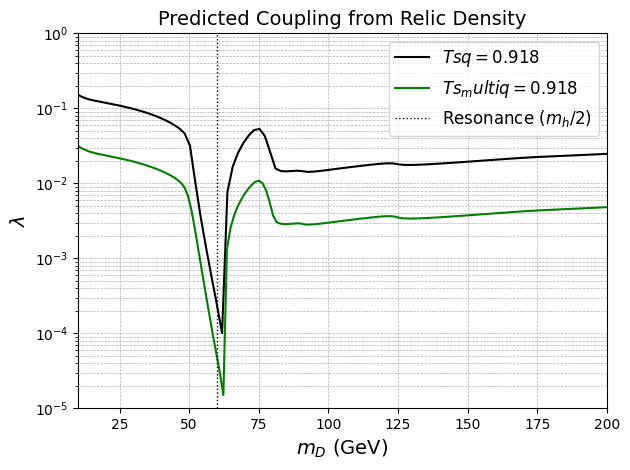

In [23]:
#Showing couplings

#plt.plot(BG_masses,BG_couplings, color='Blue', linewidth=1.5, label=f'$BG$')
plt.plot(Ts_masses,Ts_couplings_1, color='black', linewidth=1.5, label =f'$Ts q = {q_values[0]}$')
#plt.plot(Ts_masses,Ts_couplings_2, color='black', linewidth=1.5, label =f'$Ts q = {q_values[1]}$')
#plt.plot(Ts_masses,Ts_couplings_3, color='black', linewidth=1.5, label =f'$Ts q = {q_values[-1]}$')
plt.plot(Ts_multi_masses,Ts_multi_couplings[0], color='green', linewidth=1.5, label =f'$Ts_multi q = {q_values[0]}$')
#plt.plot(Ts_multi_masses,Ts_multi_couplings[-1], color='green', linewidth=1.5, label =f'$Ts q_multi = {q_values[1]}$')
#plt.plot(Ts_multi_masses,Ts_multi_couplings[-1], color='green', linewidth=1.5, label =f'$Ts q_multi = {q_values[-1]}$')

# Set Logarithmic Scale on Y-axis
plt.yscale('log')

# Formatting labels and limits to match the paper style
plt.xlabel(r'$m_D$ (GeV)', fontsize=14)
plt.ylabel(r'$\lambda$', fontsize=14)
plt.title('Predicted Coupling from Relic Density', fontsize=14)

# Set limits similar to Figure 1 
plt.xlim(10, 200)  # Adjust lower limit if your resonance dip goes deeper
plt.ylim(1e-5, 1.0)
plt.axvline(x=60, color='black', linestyle=':', linewidth=1.0, label='Resonance ($m_h/2$)')
# Add grid and legend
plt.grid(True, which="both", linestyle='--', linewidth=0.5)
plt.legend(fontsize=12)

# Show the plot

plt.tight_layout()
plt.savefig(r'/home/ethan/repos/DM-tsallis-q-statistics/Plots/Safety_checks/comparing_methods')
plt.show()